In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import label


In [3]:
DATASET_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"
SAVE_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"
EXPERIMENT_ROOT = "/work/tmp/Carina/VS_Data_Notebook/experiment"

os.makedirs(SAVE_ROOT, exist_ok=True)
os.makedirs(EXPERIMENT_ROOT, exist_ok=True)


In [4]:
TRAIN_SEQS = ["seq1", "seq4", "seq6", "seq9", "seq10", "seq11", "seq12", "seq14", "seq32", "seq33", "seq35"]
VAL_SEQS   = ["seq18", "seq20"]
TEST_SEQS  = ["seq21", "seq28", "seq37"]

In [5]:
CAR_COLORS = [
    np.array([64, 0, 128]),     # vehicle type 1
    np.array([192, 0, 192])     # vehicle type 2
]

In [6]:
def build_car_mask(label_rgb):
    car_mask = np.zeros(label_rgb.shape[:2], dtype=bool)
    for color in CAR_COLORS:
        car_mask |= np.all(label_rgb == color, axis=-1)
    return car_mask


def get_bbox(instance_mask):
    ys, xs = np.where(instance_mask)
    return ys.min(), ys.max(), xs.min(), xs.max()


def pad_to_size(img, target_h, target_w):
    h, w, c = img.shape
    pad_h = target_h - h
    pad_w = target_w - w

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    return np.pad(
        img,
        ((top, bottom), (left, right), (0, 0)),
        mode="constant",
        constant_values=0
    )


In [7]:
import cv2

TARGET_SIZE = 512

def resize_and_pad_512(img):
    h, w, c = img.shape

    # 1. resize după latura maximă
    scale = TARGET_SIZE / max(h, w)
    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    resized = cv2.resize(
        img, (new_w, new_h), interpolation=cv2.INTER_LINEAR
    )

    # 2. padding până la 512x512
    pad_h = TARGET_SIZE - new_h
    pad_w = TARGET_SIZE - new_w

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    padded = np.pad(
        resized,
        ((top, bottom), (left, right), (0, 0)),
        mode="constant",
        constant_values=0
    )

    return padded

def resize_and_pad_mask_512(mask):
    h, w = mask.shape
    scale = TARGET_SIZE / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    resized = cv2.resize(
        mask.astype(np.uint8),
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST
    )

    pad_h = TARGET_SIZE - new_h
    pad_w = TARGET_SIZE - new_w

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    padded = np.pad(
        resized,
        ((top, bottom), (left, right)),
        mode="constant",
        constant_values=0
    )

    return padded


In [8]:
def process_single_image(rgb_path, label_path, save_dir, image_id):
    rgb = np.array(Image.open(rgb_path).convert("RGB"))
    label_rgb = np.array(Image.open(label_path).convert("RGB"))

    car_mask = build_car_mask(label_rgb)
    labeled_mask, num_objects = label(car_mask)

    if num_objects == 0:
        return

    os.makedirs(save_dir, exist_ok=True)

    car_idx = 1

    for obj_id in range(1, num_objects + 1):
        instance_mask = (labeled_mask == obj_id)

        y_min, y_max, x_min, x_max = get_bbox(instance_mask)

        rgb_crop = rgb[y_min:y_max+1, x_min:x_max+1]
        mask_crop = instance_mask[y_min:y_max+1, x_min:x_max+1]

        rgb_final = resize_and_pad_512(rgb_crop)
        mask_final = resize_and_pad_mask_512(mask_crop)

        Image.fromarray(rgb_final).save(
            f"{save_dir}/car_{car_idx:03d}.png"
        )

        Image.fromarray((mask_final * 255).astype(np.uint8)).save(
            f"{save_dir}/car_{car_idx:03d}_mask.png"
        )

        car_idx += 1


In [9]:
def process_sequence(seq_name, split):
    rgb_dir = os.path.join(DATASET_ROOT, split, seq_name, "Images")
    label_dir = os.path.join(DATASET_ROOT, split, seq_name, "Labels")

    if not os.path.exists(rgb_dir):
        raise FileNotFoundError(f"Nu există: {rgb_dir}")
    if not os.path.exists(label_dir):
        raise FileNotFoundError(f"Nu există: {label_dir}")

    image_files = sorted(os.listdir(rgb_dir))

    for img_name in image_files:
        rgb_path = os.path.join(rgb_dir, img_name)
        label_path = os.path.join(label_dir, img_name)

        image_id = os.path.splitext(img_name)[0]

        save_dir = os.path.join(
            SAVE_ROOT,
            split,
            seq_name,
            "Images",
            f"CarsFromimage{image_id}"
        )

        process_single_image(
            rgb_path,
            label_path,
            save_dir,
            image_id
        )


In [10]:
# for seq in TRAIN_SEQS:
#     process_sequence(seq, "train")

# for seq in VAL_SEQS:
#     process_sequence(seq, "valid")

# for seq in TEST_SEQS:
#     process_sequence(seq, "test")

# print("Dataset construit complet ✅")


In [11]:
def rebuild_masks_for_image(
    rgb_image_dir,
    label_image_path,
    save_label_dir
):

    os.makedirs(save_label_dir, exist_ok=True)

    # Collect existing car indices (source of truth)
    existing_ids = sorted([
        int(f.split("_")[1].split(".")[0])
        for f in os.listdir(rgb_image_dir)
        if f.startswith("car_") and f.endswith(".png")
    ])

    if not existing_ids:
        return

    # Load original label
    label_rgb = np.array(Image.open(label_image_path).convert("RGB"))
    car_mask = build_car_mask(label_rgb)

    labeled_mask, num_objects = label(car_mask)

    car_idx = 1

    for obj_id in range(1, num_objects + 1):
        if car_idx not in existing_ids:
            car_idx += 1
            continue

        instance_mask = (labeled_mask == obj_id)
        y_min, y_max, x_min, x_max = get_bbox(instance_mask)

        mask_crop = instance_mask[y_min:y_max+1, x_min:x_max+1]
        mask_512 = resize_and_pad_mask_512(mask_crop)

        save_path = os.path.join(
            save_label_dir,
            f"car_{car_idx:03d}.png"
        )

        Image.fromarray((mask_512 * 255).astype(np.uint8)).save(save_path)

        car_idx += 1


In [12]:
# DATASET_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"
# SAVE_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"

# for split in ["train", "valid", "test"]:
#     split_root = os.path.join(SAVE_ROOT, split)

#     for seq in os.listdir(split_root):
#         seq_root = os.path.join(split_root, seq)

#         images_root = os.path.join(seq_root, "Images")
#         labels_root = os.path.join(seq_root, "Labels")

#         orig_label_dir = os.path.join(DATASET_ROOT, split, seq, "Labels")

#         for cars_folder in os.listdir(images_root):
#             if not cars_folder.startswith("CarsFromimage"):
#                 continue

#             image_id = cars_folder.replace("CarsFromimage", "")
#             label_path = os.path.join(orig_label_dir, image_id + ".png")

#             rebuild_masks_for_image(
#                 rgb_image_dir=os.path.join(images_root, cars_folder),
#                 label_image_path=label_path,
#                 save_label_dir=os.path.join(labels_root, cars_folder)
#             )

# print("✅ Masks rebuilt & aligned perfectly")


In [13]:
import os

DATASET_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"
SPLITS = ["train", "valid", "test"]

to_delete = []

for split in SPLITS:
    how_many = 0
    split_root = os.path.join(DATASET_ROOT, split)

    for seq in os.listdir(split_root):
        seq_root = os.path.join(split_root, seq)

        images_root = os.path.join(seq_root, "Images")
        labels_root = os.path.join(seq_root, "Labels")

        if not os.path.isdir(images_root) or not os.path.isdir(labels_root):
            continue

        for cars_folder in os.listdir(images_root):
            if not cars_folder.startswith("CarsFromimage"):
                continue

            img_dir = os.path.join(images_root, cars_folder)
            #lbl_dir = os.path.join(labels_root, cars_folder)

            # if not os.path.isdir(lbl_dir):
            #     continue  # no labels at all → skip or handle separately

            # label_names = {
            #     os.path.splitext(f)[0]
            #     for f in os.listdir(lbl_dir)
            #     if f.endswith(".png")
            # }

            for img in os.listdir(img_dir):
                if not img.endswith(".png"):
                    continue

                img_id = os.path.splitext(img)[0]
                how_many +=1

                # if img_id not in label_names:
                #     to_delete.append(os.path.join(img_dir, img))
    print(how_many)

# print(f"Images without labels: {len(to_delete)}")
# c = 0
# for p in to_delete[:100]:
#     print("WOULD DELETE:", p)
#     if p.startswith("/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/train/seq6/Images/CarsFromimage000000"):
#         c += 1



7077
2298
2301


In [14]:
# import os

# DATASET_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"
# SPLITS = ["train", "valid", "test"]

# deleted = 0

# for split in SPLITS:
#     split_root = os.path.join(DATASET_ROOT, split)

#     for seq in os.listdir(split_root):
#         seq_root = os.path.join(split_root, seq)

#         images_root = os.path.join(seq_root, "Images")
#         labels_root = os.path.join(seq_root, "Labels")
        
#         if not os.path.isdir(images_root) or not os.path.isdir(labels_root):
#             continue

#         for cars_folder in os.listdir(images_root):
#             if not cars_folder.startswith("CarsFromimage"):
#                 continue

#             img_dir = os.path.join(images_root, cars_folder)
#             lbl_dir = os.path.join(labels_root, cars_folder)

#             if not os.path.isdir(lbl_dir):
#                 continue

#             label_names = {
#                 os.path.splitext(f)[0]
#                 for f in os.listdir(lbl_dir)
#                 if f.endswith(".png")
#             }

#             for img in os.listdir(img_dir):
#                 if not img.endswith(".png"):
#                     continue

#                 img_path = os.path.join(img_dir, img)
#                 img_id = os.path.splitext(img)[0]

#                 if img_id not in label_names:
#                     os.remove(img_path)
#                     deleted += 1

# print(f"Deleted {deleted} images without labels.")


In [15]:
import cv2
import numpy as np

def mask_to_heatmap(mask):
    # Ensure binary {0,1}
    mask = (mask > 0).astype(np.uint8)

    # Distance transform (inside object only)
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)

    if dist.max() > 0:
        dist = dist / dist.max()

    return dist.astype(np.float32)


In [16]:
from PIL import Image
import os

def generate_heatmaps_for_folder(mask_dir, heatmap_dir):
    os.makedirs(heatmap_dir, exist_ok=True)

    for fname in sorted(os.listdir(mask_dir)):
        if not fname.endswith(".png"):
            continue

        mask_path = os.path.join(mask_dir, fname)
        mask = np.array(Image.open(mask_path).convert("L"))

        heatmap = mask_to_heatmap(mask)

        save_path = os.path.join(
            heatmap_dir,
            fname.replace(".png", ".npy")
        )

        np.save(save_path, heatmap)


In [17]:
# BASE = "/content/drive/MyDrive/UAVid_cars_dataset"

# for split in ["train", "valid"]:
#     split_root = os.path.join(BASE, split)

#     for seq in os.listdir(split_root):
#         seq_root = os.path.join(split_root, seq)

#         labels_root = os.path.join(seq_root, "Labels")
#         heatmaps_root = os.path.join(seq_root, "Heatmaps")

#         if not os.path.exists(labels_root):
#             continue

#         for cars_folder in os.listdir(labels_root):
#             generate_heatmaps_for_folder(
#                 mask_dir=os.path.join(labels_root, cars_folder),
#                 heatmap_dir=os.path.join(heatmaps_root, cars_folder)
#             )

# print("✅ Heatmaps generated")

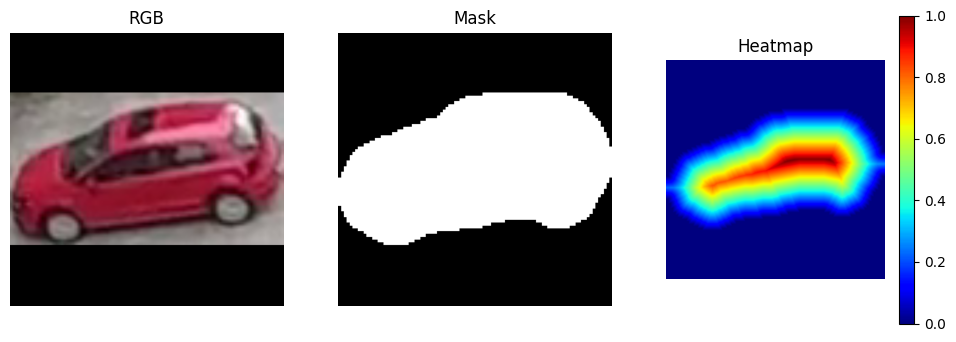

In [18]:
import matplotlib.pyplot as plt

rgb = Image.open("/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/train/seq1/Images/CarsFromimage000000/car_048.png")
mask = Image.open("/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/train/seq1/Labels/CarsFromimage000000/car_048.png")
heatmap = np.load("/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/train/seq1/Heatmaps/CarsFromimage000000/car_048.npy")

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("RGB")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.axis("off")

plt.show()


In [1]:
import os
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)


Using device: cuda


In [2]:
#using_colab = False

%pip uninstall -y jax jaxlib shap pytensor opencv-python opencv-python-headless opencv-contrib-python
%pip install "numpy>=1.26,<2.0"
%pip install "opencv-python<4.10"
%pip install decord

#if using_colab:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
%pip install opencv-python matplotlib scikit-learn
%pip install 'git+https://github.com/facebookresearch/sam3.git'
%pip install einops
%pip install pycocotools
#%{sys.executable} -m pip install opencv-python matplotlib scikit-learn
#%{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

Found existing installation: opencv-python 4.9.0.80
Uninstalling opencv-python-4.9.0.80:
  Successfully uninstalled opencv-python-4.9.0.80
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.2 MB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PyTorch version: 2.9.1+cu128
Torchvision version: 0.24.1+cu128
CUDA is available: True
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/facebookresearch/sam3.git to /tmp/pip-req-build-qa7kae8e
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam3.git /tmp/pip-req-build-qa7kae8e
  Resolved http

In [3]:
import os
os.environ["HF_TOKEN"] = "hf_PUNE_TOKENUL_TAU_AICI"
from huggingface_hub import whoami
print(whoami())

/home/cbojan/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'type': 'user', 'id': '688e03f0c38838e091f48f92', 'name': 'carinabojan', 'fullname': 'Carina Bojan', 'isPro': False, 'avatarUrl': '/avatars/d5c650eb9c3fa489a855ffb8b26f08b3.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'LocallySAM3', 'role': 'fineGrained', 'createdAt': '2026-01-12T19:16:13.051Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '690d80fc9f252aa897a1dc6d', 'type': 'model', 'name': 'facebook/sam3'}, 'permissions': ['repo.content.read']}, {'entity': {'_id': '688e03f0c38838e091f48f92', 'type': 'user', 'name': 'carinabojan'}, 'permissions': ['repo.content.read']}]}}}}


In [4]:
from huggingface_hub import hf_hub_download

hf_hub_download(
    repo_id="facebook/sam3",
    filename="config.json",
)

'/home/cbojan/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/config.json'

In [5]:

import os
import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

/home/cbojan/miniconda3/lib/python3.13/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


sam3_root = os.path.dirname(sam3.__file__)
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"

sam_model = build_sam3_image_model(
    bpe_path=bpe_path,
    enable_inst_interactivity=True
)

processor = Sam3Processor(sam_model)

print("SAM loaded.")

Using device: cuda
SAM loaded.


In [7]:
# ===== IOU =====

def compute_iou(pred_mask, gt_mask):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 0.0

    return intersection / union


# ===== RANDOM POINT SAMPLER =====

def sample_random_points_from_mask(mask, k=3):
    ys, xs = torch.where(mask[0] > 0.5)

    if len(xs) < k:
        idx = torch.randint(0, len(xs), (k,))
    else:
        idx = torch.randperm(len(xs))[:k]

    pts = torch.stack([xs[idx], ys[idx]], dim=1).float()
    pts[:, 0] /= 512
    pts[:, 1] /= 512

    return pts

In [8]:
# CONFIG = {
#     "batch_size": 8,
#     "num_epochs": 45,          
#     "learning_rate": 1e-4,    
#     "dropout": 0.1,
#     "supervision_type": "mask",

#     # early stopping
#     "early_stop_patience": 7,
#     "early_stop_min_delta": 5e-4,
# }

CONFIG = {
    "batch_size": 8,
    "num_epochs": 3,
    "learning_rate": 1e-4,
    "supervision_type": "mask",
    "dropout": 0.1,
    "num_points": 3,
    "exploration_std": 0.02,
    "image_size": 512,
    "diversity_weight": 0.2,
    "diversity_margin": 0.15,
    "policy_std": 0.05
}


In [9]:
class CarPromptDatasetSplit(Dataset):
    def __init__(self, split_root, supervision_type="heatmap"):
        assert supervision_type in ["mask", "heatmap"]
        self.supervision_type = supervision_type
        self.samples = []

        for seq in sorted(os.listdir(split_root)):
            seq_root = os.path.join(split_root, seq)
            images_root = os.path.join(seq_root, "Images")
            labels_root = os.path.join(seq_root, "Labels")
            heatmaps_root = os.path.join(seq_root, "Heatmaps")

            if not os.path.isdir(images_root):
                continue

            for cars_folder in sorted(os.listdir(images_root)):
                img_dir = os.path.join(images_root, cars_folder)
                if not os.path.isdir(img_dir):
                    continue

                if supervision_type == "mask":
                    tgt_dir = os.path.join(labels_root, cars_folder)
                else:
                    tgt_dir = os.path.join(heatmaps_root, cars_folder)

                if not os.path.isdir(tgt_dir):
                    continue

                for fname in sorted(os.listdir(img_dir)):
                    if not fname.startswith("car_"):
                        continue

                    img_path = os.path.join(img_dir, fname)

                    if supervision_type == "mask":
                        tgt_path = os.path.join(tgt_dir, fname)
                    else:
                        tgt_path = os.path.join(tgt_dir, fname.replace(".png", ".npy"))

                    if os.path.exists(tgt_path):
                        self.samples.append((img_path, tgt_path))

    def __len__(self):
        return len(self.samples)
    

    # #first version when predicted heatmaps and extracted points from them
    # def __getitem__(self, idx):
    #     img_path, tgt_path = self.samples[idx]

    #     img = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
    #     img = torch.from_numpy(img).permute(2, 0, 1).float()

    #     if self.supervision_type == "heatmap":
    #         target = np.load(tgt_path).astype(np.float32)
    #     else:
    #         target = np.array(Image.open(tgt_path).convert("L"), dtype=np.float32) / 255.0

    #     target = torch.from_numpy(target).unsqueeze(0).float()
    #     return img, target

    #second version predicted points starting from random values
    def __getitem__(self, idx):
        img_path, tgt_path = self.samples[idx]

        img = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1).float()

        if self.supervision_type == "mask":
            target = np.array(Image.open(tgt_path).convert("L"), dtype=np.float32) / 255.0
        else:
            target = np.load(tgt_path).astype(np.float32)

        target = torch.from_numpy(target).unsqueeze(0).float()

        return img, target, img_path

In [10]:
class CarRGBTestDatasetSplit(Dataset):
    def __init__(self, split_root):
        self.images = []

        for seq in sorted(os.listdir(split_root)):
            seq_root = os.path.join(split_root, seq)
            images_root = os.path.join(seq_root, "Images")

            if not os.path.isdir(images_root):
                continue

            for cars_folder in sorted(os.listdir(images_root)):
                img_dir = os.path.join(images_root, cars_folder)
                if not os.path.isdir(img_dir):
                    continue

                for fname in sorted(os.listdir(img_dir)):
                    if fname.startswith("car_") and fname.endswith(".png"):
                        self.images.append(os.path.join(img_dir, fname))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        return img, img_path


In [11]:
BASE = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset"

train_dataset = CarPromptDatasetSplit(
    os.path.join(BASE, "train"),
    CONFIG["supervision_type"]
)

valid_dataset = CarPromptDatasetSplit(
    os.path.join(BASE, "valid"),
    CONFIG["supervision_type"]
)

test_dataset = CarRGBTestDatasetSplit(
    os.path.join(BASE, "test")
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))


Train: 7077
Valid: 2298
Test : 2301


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=0
)


In [13]:
print("Train loader batches:", len(train_loader))
print("Valid loader batches:", len(valid_loader))


Train loader batches: 885
Valid loader batches: 288


In [26]:
#version that predicted heatmaps
# class PromptCNN(nn.Module):
#     def __init__(self, dropout):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv2d(3, 32, 3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(32, 64, 3, padding=1), 
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(64, 64, 3, padding=1),
#             nn.ReLU(),
#             nn.Dropout2d(dropout),

#             nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False),
#             nn.Conv2d(64, 1, 1),
#         )

#     def forward(self, x):
#         return self.net(x)


In [14]:
#architecture that predicts 3 points per img
class PromptCNN(nn.Module):
    def __init__(self, dropout, k=3):
        super().__init__()
        self.k = k

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, k * 2)
        )

    def forward(self, x):
        x = self.features(x)
        coords = self.fc(x)
        coords = torch.sigmoid(coords) 
        return coords.view(-1, self.k, 2)

In [15]:
EXP_ROOT = "/work/tmp/Carina/VS_Data_Notebook/experiment_points/prompt_cnn/Test5"

CKPT_DIR = os.path.join(EXP_ROOT, "checkpoints")
LOG_DIR  = os.path.join(EXP_ROOT, "logs")
TEST_OUT = os.path.join(EXP_ROOT, "test_predictions")

VIS_DIR  = os.path.join(EXP_ROOT, "visuals")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(TEST_OUT, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print("Experiment folders ready")


Experiment folders ready


In [16]:
best_points = {}
best_ious = {}

print("Initializing best points...")

for img, mask, path in tqdm(train_dataset):
    pts = sample_random_points_from_mask(mask, k=3)
    best_points[path] = pts
    best_ious[path] = 0.0

print("Initialization done.")

Initializing best points...


100%|██████████| 7077/7077 [00:52<00:00, 135.87it/s]

Initialization done.


In [50]:
## version when predicted output was a heatmap
# from tqdm import tqdm

# def train_and_validate(model):
#     if CONFIG["supervision_type"] == "heatmap":
#         criterion = nn.MSELoss()
#     else:
#         criterion = nn.BCEWithLogitsLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
#     model.to(device)

#     train_losses = []
#     valid_losses = []
#     best_valid = float("inf")

#     for epoch in range(CONFIG["num_epochs"]):
#         #TRAIN 
#         model.train()
#         train_loss = 0.0

#         train_bar = tqdm(
#             train_loader,
#             desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']} [TRAIN]",
#             leave=False
#         )

#         for images, targets in train_bar:
#             images = images.to(device)
#             targets = targets.to(device)

#             preds = model(images)
#             loss = criterion(preds, targets)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
#             train_bar.set_postfix(loss=f"{loss.item():.5f}")

#         train_loss /= len(train_loader)
#         train_losses.append(train_loss)

#         # VALID
#         model.eval()
#         valid_loss = 0.0

#         valid_bar = tqdm(
#             valid_loader,
#             desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']} [VALID]",
#             leave=False
#         )

#         with torch.no_grad():
#             for images, targets in valid_bar:
#                 images = images.to(device)
#                 targets = targets.to(device)

#                 preds = model(images)
#                 loss = criterion(preds, targets)
#                 valid_loss += loss.item()
#                 valid_bar.set_postfix(loss=f"{loss.item():.5f}")

#         valid_loss /= len(valid_loader)
#         valid_losses.append(valid_loss)

#         # EPOCH SUMMARY
#         print(
#             f"Epoch {epoch+1}/{CONFIG['num_epochs']} | "
#             f"Train Loss: {train_loss:.6f} | "
#             f"Valid Loss: {valid_loss:.6f}"
#         )

#         # SAVE BEST
#         if valid_loss < best_valid:
#             best_valid = valid_loss
#             torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_model.pth"))
#             print("✓ Best model saved")

#     np.save(os.path.join(LOG_DIR, "train_losses.npy"), np.array(train_losses))
#     np.save(os.path.join(LOG_DIR, "valid_losses.npy"), np.array(valid_losses))

#     print("Training finished.")


In [16]:
def diversity_loss(points, margin=0.1):
    """
    Encourage points to stay apart.
    points: (B, k, 2) normalized [0,1]
    """
    B, k, _ = points.shape
    loss = 0.0

    for i in range(k):
        for j in range(i+1, k):
            dist = torch.norm(points[:, i] - points[:, j], dim=1)
            penalty = torch.clamp(margin - dist, min=0.0)
            loss += penalty.mean()

    return loss

In [18]:
def train_policy_gradient(model, epochs):

    model = model.to(device).float()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

    train_iou_history = []
    val_iou_history = []
    train_loss_history = []
    val_loss_history = []

    best_val = -1.0
    best_epoch = -1

    baseline = 0.0

    for epoch in range(epochs):

        # ======================================================
        # TRAINING
        # ======================================================
        model.train()
        epoch_rewards = []
        epoch_losses = []

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for images, masks, _ in train_bar:

            images = images.to(device).float()
            B = images.size(0)

            mu = model(images).float()

            std = CONFIG["policy_std"]
            dist = torch.distributions.Normal(mu, std)

            sampled_points = dist.rsample().float()
            sampled_points = torch.clamp(sampled_points, 0.0, 1.0)

            log_probs = dist.log_prob(sampled_points).sum(dim=[1,2])

            rewards = []

            for i in range(B):

                pts = sampled_points[i].detach().float()

                pts_px = pts.clone()
                pts_px[:,0] *= CONFIG["image_size"]
                pts_px[:,1] *= CONFIG["image_size"]

                point_coords = pts_px.cpu().numpy().astype(np.float32)
                point_labels = np.ones(CONFIG["num_points"], dtype=np.int32)

                image_np = images[i].detach().cpu().permute(1,2,0).numpy()
                image_np = (image_np * 255).astype(np.uint8)

                gt_mask = masks[i][0].numpy() > 0.5

                inference_state = processor.set_image(image_np)

                sam_masks, scores, _ = sam_model.predict_inst(
                    inference_state,
                    point_coords=point_coords,
                    point_labels=point_labels,
                    multimask_output=True,
                )

                sam_masks = np.array(sam_masks)
                if sam_masks.ndim == 3 and sam_masks.shape[-1] == len(scores):
                    sam_masks = np.transpose(sam_masks, (2,0,1))

                sam_mask = sam_masks[np.argmax(scores)].squeeze()

                if sam_mask.ndim == 3:
                    sam_mask = sam_mask[..., 0]

                if sam_mask.shape != gt_mask.shape:
                    sam_mask = Image.fromarray(sam_mask.astype(np.uint8))
                    sam_mask = sam_mask.resize(
                        (CONFIG["image_size"], CONFIG["image_size"]),
                        resample=Image.NEAREST
                    )
                    sam_mask = np.array(sam_mask)

                iou = compute_iou(sam_mask, gt_mask)
                rewards.append(iou)

            rewards = torch.tensor(rewards, device=device).float()

            epoch_rewards.extend(rewards.cpu().tolist())

            # Moving baseline
            baseline = 0.9 * baseline + 0.1 * rewards.mean().item()

            advantage = rewards - baseline
            loss = -(log_probs * advantage.detach()).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        train_mean_iou = float(np.mean(epoch_rewards))
        train_mean_loss = float(np.mean(epoch_losses))

        train_iou_history.append(train_mean_iou)
        train_loss_history.append(train_mean_loss)

        # ======================================================
        # VALIDATION
        # ======================================================
        model.eval()
        val_ious = []
        val_losses = []

        val_bar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]")

        with torch.no_grad():

            for images, masks, _ in val_bar:

                images = images.to(device).float()
                B = images.size(0)

                mu = model(images).float()

                std = CONFIG["policy_std"]
                dist = torch.distributions.Normal(mu, std)

                log_probs = dist.log_prob(mu).sum(dim=[1,2])

                rewards = []

                for i in range(B):

                    pts = mu[i].detach().float()

                    pts_px = pts.clone()
                    pts_px[:,0] *= CONFIG["image_size"]
                    pts_px[:,1] *= CONFIG["image_size"]

                    point_coords = pts_px.cpu().numpy().astype(np.float32)
                    point_labels = np.ones(CONFIG["num_points"], dtype=np.int32)

                    image_np = images[i].detach().cpu().permute(1,2,0).numpy()
                    image_np = (image_np * 255).astype(np.uint8)

                    gt_mask = masks[i][0].numpy() > 0.5

                    inference_state = processor.set_image(image_np)

                    sam_masks, scores, _ = sam_model.predict_inst(
                        inference_state,
                        point_coords=point_coords,
                        point_labels=point_labels,
                        multimask_output=True,
                    )

                    sam_masks = np.array(sam_masks)
                    if sam_masks.ndim == 3 and sam_masks.shape[-1] == len(scores):
                        sam_masks = np.transpose(sam_masks, (2,0,1))

                    sam_mask = sam_masks[np.argmax(scores)].squeeze()

                    if sam_mask.ndim == 3:
                        sam_mask = sam_mask[..., 0]

                    if sam_mask.shape != gt_mask.shape:
                        sam_mask = Image.fromarray(sam_mask.astype(np.uint8))
                        sam_mask = sam_mask.resize(
                            (CONFIG["image_size"], CONFIG["image_size"]),
                            resample=Image.NEAREST
                        )
                        sam_mask = np.array(sam_mask)

                    iou = compute_iou(sam_mask, gt_mask)
                    rewards.append(iou)

                rewards = torch.tensor(rewards, device=device).float()

                val_ious.extend(rewards.cpu().tolist())

                val_loss = -(log_probs * (rewards - baseline)).mean()
                val_losses.append(val_loss.item())

        val_mean_iou = float(np.mean(val_ious))
        val_mean_loss = float(np.mean(val_losses))

        val_iou_history.append(val_mean_iou)
        val_loss_history.append(val_mean_loss)

        print("\n" + "="*60)
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss      : {train_mean_loss:.6f}")
        print(f"Train IoU       : {train_mean_iou:.4f}")
        print(f"Validation Loss : {val_mean_loss:.6f}")
        print(f"Validation IoU  : {val_mean_iou:.4f}")
        print("="*60)

        if val_mean_iou > best_val:
            best_val = val_mean_iou
            best_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(CKPT_DIR,"best_model.pth"))
            print("✓ Saved best model")

    np.save(os.path.join(LOG_DIR,"train_loss.npy"), np.array(train_loss_history))
    np.save(os.path.join(LOG_DIR,"val_loss.npy"), np.array(val_loss_history))
    np.save(os.path.join(LOG_DIR,"train_iou.npy"), np.array(train_iou_history))
    np.save(os.path.join(LOG_DIR,"val_iou.npy"), np.array(val_iou_history))

    print(f"\nBest Epoch: {best_epoch} | Best Val IoU: {best_val:.4f}")

In [19]:
# model = PromptCNN(dropout=CONFIG["dropout"])
# train_and_validate(model)

model = PromptCNN(
    dropout=CONFIG["dropout"],
    k=CONFIG["num_points"]
)

train_policy_gradient(model, epochs=CONFIG["num_epochs"])

Epoch 1/3 [Validation]: 100%|██████████| 288/288 [11:13<00:00,  2.34s/it]



Epoch 1/3
Train Loss      : -0.038380
Train IoU       : 0.3865
Validation Loss : 1.332982
Validation IoU  : 0.2558
✓ Saved best model


Epoch 2/3 [Validation]: 100%|██████████| 288/288 [11:37<00:00,  2.42s/it]



Epoch 2/3
Train Loss      : -0.001474
Train IoU       : 0.3864
Validation Loss : 1.498700
Validation IoU  : 0.2558


Epoch 3/3 [Validation]: 100%|██████████| 288/288 [12:32<00:00,  2.61s/it]


Epoch 3/3
Train Loss      : -0.001069
Train IoU       : 0.3847
Validation Loss : 1.444157
Validation IoU  : 0.2558

Best Epoch: 1 | Best Val IoU: 0.2558


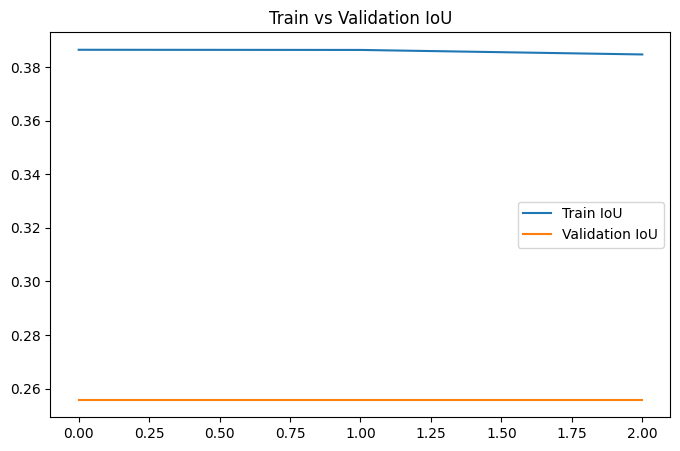

In [20]:
plt.figure(figsize=(8,5))
plt.plot(np.load(os.path.join(LOG_DIR,"train_iou.npy")), label="Train IoU")
plt.plot(np.load(os.path.join(LOG_DIR,"val_iou.npy")), label="Validation IoU")
plt.legend()
plt.title("Train vs Validation IoU")
plt.show()

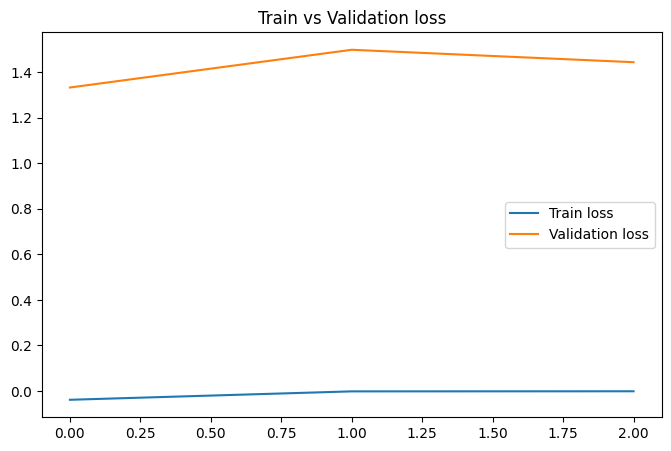

In [21]:
plt.figure(figsize=(8,5))
plt.plot(np.load(os.path.join(LOG_DIR,"train_loss.npy")), label="Train loss")
plt.plot(np.load(os.path.join(LOG_DIR,"val_loss.npy")), label="Validation loss")
plt.legend()
plt.title("Train vs Validation loss")
plt.show()

In [ ]:
##for heatmaps
# model.load_state_dict(
#     torch.load(os.path.join(CKPT_DIR, "best_model.pth"), map_location=device)
# )
# model.eval()

# with torch.no_grad():
#     for img, img_path in test_dataset:
#         img = img.unsqueeze(0).to(device)

#         logits = model(img)                  
#         probs = torch.sigmoid(logits)        

#         pred = probs.cpu()[0, 0].numpy()    

#         rel_path = img_path.replace(
#             "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/test/", ""
#         )
#         out_path = os.path.join(TEST_OUT, rel_path)
#         out_path = out_path.replace(".png", ".npy")

#         os.makedirs(os.path.dirname(out_path), exist_ok=True)
#         np.save(out_path, pred)

# print("Test probability maps saved")


In [22]:
def visualize_prediction(image_np, point_coords, sam_mask, save_path):

    plt.figure(figsize=(6,6))
    plt.imshow(image_np)

    # ---- Overlay SAM mask (blue transparent) ----
    mask = sam_mask.astype(np.uint8)
    overlay = np.zeros((mask.shape[0], mask.shape[1], 4))
    overlay[..., 2] = 1.0          # blue channel
    overlay[..., 3] = mask * 0.4   # alpha

    plt.imshow(overlay)

    # ---- Plot predicted points ----
    for (x, y) in point_coords:
        plt.scatter(
            x, y,
            c='lime',
            s=150,
            marker='*',
            edgecolors='white',
            linewidths=1.5
        )

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

In [23]:
# ===== LOAD BEST MODEL =====

model.load_state_dict(
    torch.load(
        os.path.join(CKPT_DIR, "best_model.pth"),
        map_location=device
    )
)

model = model.to(device).float()
model.eval()

print("Loaded BEST model. Running test inference...")

with torch.no_grad():

    for idx, (img, img_path) in enumerate(tqdm(test_dataset)):

        img_tensor = img.unsqueeze(0).to(device).float()

        # Predict normalized points
        preds = model(img_tensor).float()[0].cpu()

        # Convert to pixel coords
        pts_px = preds.clone().float()
        pts_px[:, 0] *= CONFIG["image_size"]
        pts_px[:, 1] *= CONFIG["image_size"]

        point_coords = pts_px.numpy().astype(np.float32)
        point_labels = np.ones(CONFIG["num_points"], dtype=np.int32)

        # Prepare image for SAM
        image_np = img.permute(1,2,0).numpy()
        image_uint8 = (image_np * 255).astype(np.uint8)

        inference_state = processor.set_image(image_uint8)

        # Run SAM
        masks, scores, _ = sam_model.predict_inst(
            inference_state,
            point_coords=point_coords,
            point_labels=point_labels,
            multimask_output=True,
        )

        sam_masks = np.array(masks)

        # Fix possible (H,W,K) format
        if sam_masks.ndim == 3 and sam_masks.shape[-1] == len(scores):
            sam_masks = np.transpose(sam_masks, (2,0,1))

        sam_mask = sam_masks[np.argmax(scores)]
        sam_mask = sam_mask.squeeze()

        # ===== SAVE OUTPUTS =====
        rel_path = img_path.replace(
            "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/test/", ""
        )

        base_out = os.path.join(TEST_OUT, rel_path.replace(".png", ""))
        os.makedirs(os.path.dirname(base_out), exist_ok=True)

        # Save points
        np.savez(
            base_out + "_points.npz",
            point_coords=point_coords,
            point_labels=point_labels
        )

        # Save mask
        np.save(base_out + "_mask.npy", sam_mask)

        mask_uint8 = (sam_mask.astype(np.uint8) * 255)
        Image.fromarray(mask_uint8).save(base_out + "_mask.png")

        # ===== SAVE VISUALIZATION =====
        vis_out = os.path.join(
            VIS_DIR,
            rel_path.replace(".png", "_vis1.png")
        )
        os.makedirs(os.path.dirname(vis_out), exist_ok=True)

        visualize_prediction(
            image_uint8,
            point_coords,
            sam_mask,
            vis_out
        )

        # Optional: limit to first 50 images for debugging
        # if idx >= 50:
        #     break

print("Test inference + visualization finished.")

Loaded BEST model. Running test inference...


100%|██████████| 2301/2301 [16:17<00:00,  2.35it/s]

Test inference + visualization finished.


Found 2301 visualization images.


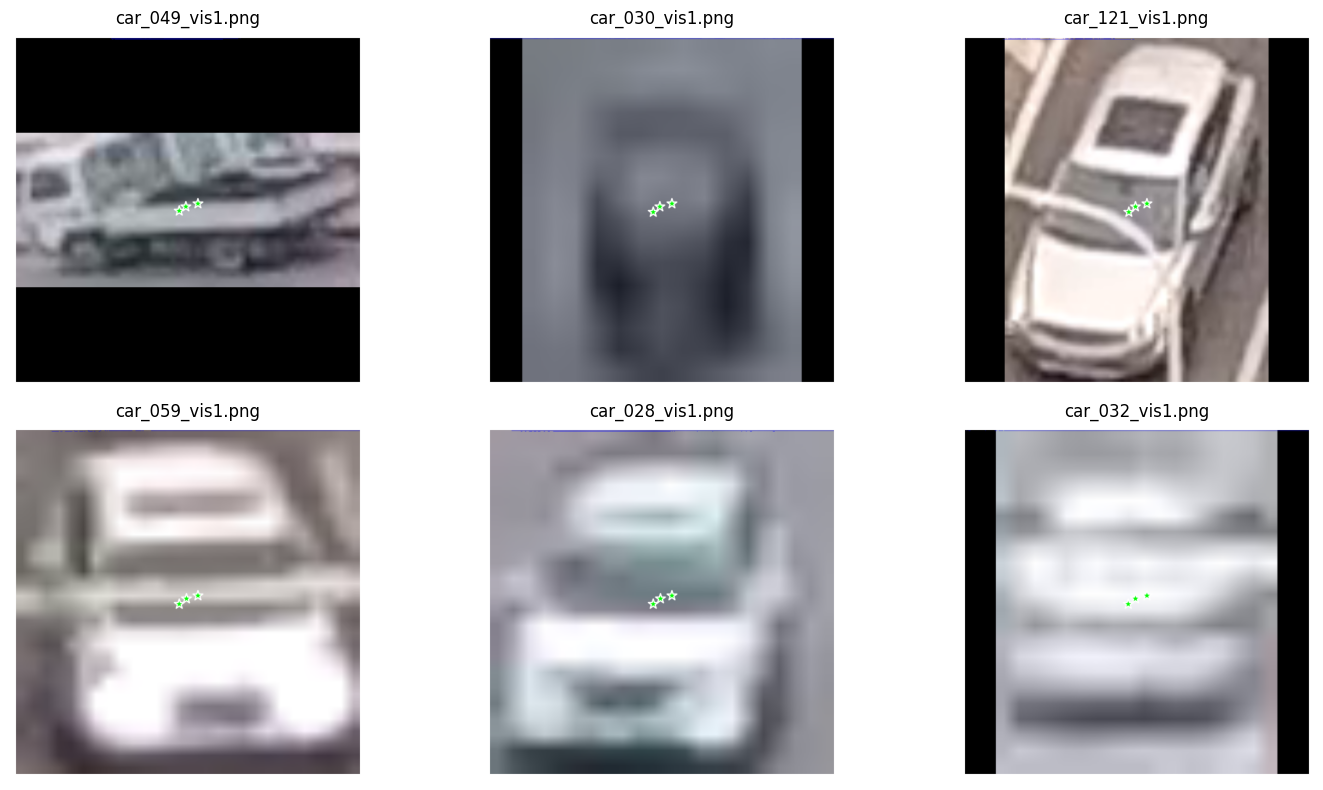

In [25]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# how many images to display
num_to_show = 6

# collect all saved visualization files
vis_files = []

for root, _, files in os.walk(VIS_DIR):
    for f in files:
        if f.endswith("_vis1.png"):
            vis_files.append(os.path.join(root, f))

print(f"Found {len(vis_files)} visualization images.")

# randomly pick some
vis_files = random.sample(vis_files, min(num_to_show, len(vis_files)))

# display
plt.figure(figsize=(15, 8))

for i, vis_path in enumerate(vis_files):
    img = Image.open(vis_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(vis_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def extract_topk_points(
    score_map,
    k,
    min_distance,
    threshold,
):
    """
    score_map: (H, W) numpy array
    returns: (N, 2) array of (x, y)
    """

    hmap = score_map.copy()
    points = []

    if threshold is not None:
        hmap[hmap < threshold] = 0

    for _ in range(k):
        idx = np.argmax(hmap)
        val = hmap.flat[idx]

        if val <= 0:
            break

        y, x = np.unravel_index(idx, hmap.shape)
        points.append((x, y))

        # suppress neighborhood so we don't pick the same region again
        y0 = max(0, y - min_distance)
        y1 = min(hmap.shape[0], y + min_distance)
        x0 = max(0, x - min_distance)
        x1 = min(hmap.shape[1], x + min_distance)
        hmap[y0:y1, x0:x1] = 0

    return np.array(points, dtype=np.float32)


In [ ]:
import os
import numpy as np

TEST_PRED_ROOT = "/work/tmp/Carina/VS_Data_Notebook/experiment/prompt_cnn/Test2/test_predictions"
K = 5              # number of points you want
MIN_DISTANCE = 30     # pixels between points
THRESHOLD = None      # 0.3 for masks

for root, _, files in os.walk(TEST_PRED_ROOT):
    for fname in files:
        if not fname.endswith(".npy"):
            continue

        map_path = os.path.join(root, fname)
        score_map = np.load(map_path)

        points = extract_topk_points(
            score_map,
            k=K,
            min_distance=MIN_DISTANCE,
            threshold=THRESHOLD,
        )

        point_coords = points
        point_labels = np.ones(len(points), dtype=np.int32)

        out_path = map_path.replace(".npy", "_points.npz")

        np.savez(
            out_path,
            point_coords=point_coords,
            point_labels=point_labels,
        )

print("Point extraction finished.")


Point extraction finished.


In [ ]:
# import matplotlib.pyplot as plt

# # Folder you want to visualize
# VIZ_ROOT = (
#     "/work/tmp/Carina/VS_Data_Notebook/experiment/"
#     "prompt_cnn/Test2/test_predictions/seq21/Images/CarsFromimage000000"
# )

# # Output folder for figures
# OUT_VIZ_ROOT = os.path.join(VIZ_ROOT, "viz")
# os.makedirs(OUT_VIZ_ROOT, exist_ok=True)

# for fname in sorted(os.listdir(VIZ_ROOT)):
#     if not fname.endswith(".npy"):
#         continue

#     # skip point files themselves
#     if fname.endswith("_points.npy"):
#         continue

#     map_path = os.path.join(VIZ_ROOT, fname)
#     points_path = map_path.replace(".npy", "_points.npz")

#     if not os.path.exists(points_path):
#         print("Missing points for:", fname)
#         continue

#     # load data
#     score_map = np.load(map_path)
#     data = np.load(points_path)
#     point_coords = data["point_coords"]

#     # ---- plot ----
#     plt.figure(figsize=(5, 5))
#     plt.imshow(score_map, cmap="jet")

#     if len(point_coords) > 0:
#         plt.scatter(
#             point_coords[:, 0],
#             point_coords[:, 1],
#             c="white",
#             s=50
#         )

#     plt.title(fname.replace(".npy", ""))
#     plt.axis("off")

#     # save
#     out_png = os.path.join(
#         OUT_VIZ_ROOT,
#         fname.replace(".npy", "_heatmap_points.png")
#     )
#     plt.savefig(out_png, bbox_inches="tight", pad_inches=0)
#     plt.close()

# print("Saved heatmap + points visualizations to:", OUT_VIZ_ROOT)


Saved heatmap + points visualizations to: /work/tmp/Carina/VS_Data_Notebook/experiment/prompt_cnn/Test2/test_predictions/seq21/Images/CarsFromimage000000/viz


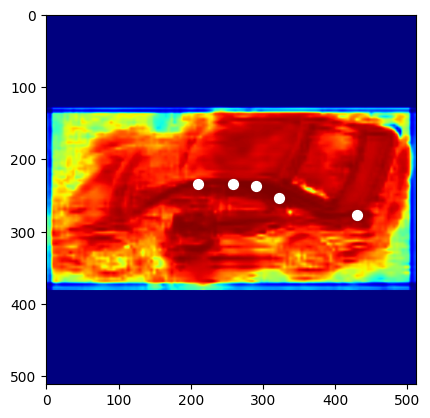

In [ ]:
import matplotlib.pyplot as plt 

plt.imshow(score_map, cmap="jet") 
plt.scatter( point_coords[:,0], 
            point_coords[:,1], 
            c="white", s=50 ) 
plt.show()

In [21]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [19]:
def compute_iou(pred_mask, gt_mask):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 0.0

    return intersection / union


In [22]:
import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
import matplotlib.pyplot as plt

sam3_root = os.path.dirname(sam3.__file__)
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"

sam_model = build_sam3_image_model(
    bpe_path=bpe_path,
    enable_inst_interactivity=True
)

processor = Sam3Processor(
    sam_model
)


found 1 object(s)


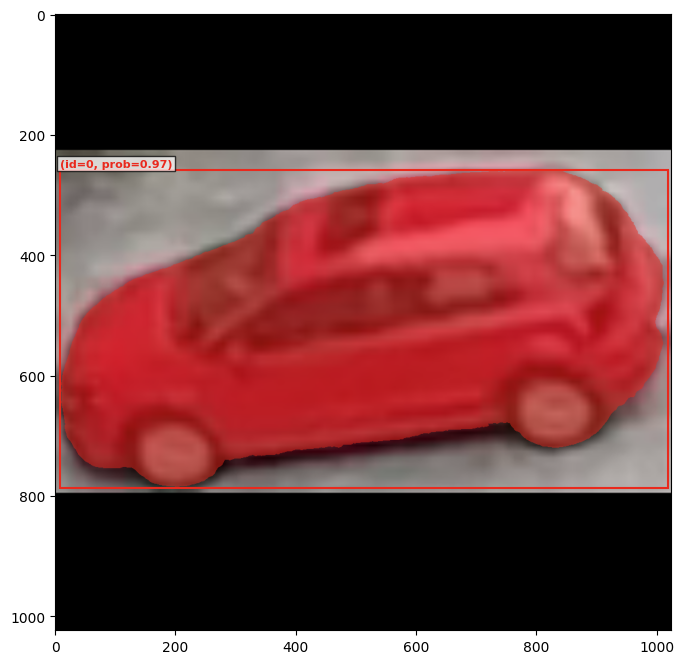

In [ ]:
#for one pic

# img = Image.open(
#     "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/train/seq1/Images/CarsFromimage000000/car_048.png"
# ).convert("RGB")

# img = img.resize((1024, 1024))

# state = processor.set_image(img)
# state = processor.set_text_prompt("car", state)

# plot_results(img, state)


In [23]:
if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

In [24]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [36]:
TEST_IMG_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/test"
TEST_POINTS_ROOT = "/work/tmp/Carina/VS_Data_Notebook/experiment/prompt_cnn/Test3/test_predictions"
GT_MASK_ROOT = "/work/tmp/Carina/VS_Data_Notebook/UAVid_cars_dataset/test"  # adjust if needed

SAM_OUT_ROOT = "/work/tmp/Carina/VS_Data_Notebook/experiment/sam3_outputs/mask_supervision_1"
os.makedirs(SAM_OUT_ROOT, exist_ok=True)

ious = []

for root, _, files in os.walk(TEST_POINTS_ROOT):
    for fname in files:
        if not fname.endswith("_points.npz"):
            continue

        points_path = os.path.join(root, fname)
        rel = os.path.relpath(points_path, TEST_POINTS_ROOT)

        img_rel = rel.replace("_points.npz", ".png")
        img_path = os.path.join(TEST_IMG_ROOT, img_rel)
        gt_mask_path = os.path.join(
            TEST_IMG_ROOT,
            img_rel.replace(
                os.path.sep + "Images" + os.path.sep,
                os.path.sep + "Labels" + os.path.sep
            )
        )

        if not os.path.exists(img_path) or not os.path.exists(gt_mask_path):
            continue

        image = Image.open(img_path).convert("RGB")
        gt_mask = np.array(Image.open(gt_mask_path).convert("L")) > 0

        inference_state = processor.set_image(image)

        data = np.load(points_path)
        point_coords = data["point_coords"].astype(np.float32)
        point_labels = data["point_labels"].astype(np.int32)

        masks, scores, _ = sam_model.predict_inst(
            inference_state,
            point_coords=point_coords,
            point_labels=point_labels,
            multimask_output=True,
        )

        sam_mask = masks[np.argmax(scores)]
        ious.append(compute_iou(sam_mask, gt_mask))

        out_mask_path = os.path.join(
            SAM_OUT_ROOT,
            rel.replace("_points.npz", "_sam3_mask.npy")
        )

        os.makedirs(os.path.dirname(out_mask_path), exist_ok=True)
        np.save(out_mask_path, sam_mask)

        mask_uint8 = (sam_mask.astype(np.uint8) * 255)

        # create PIL image
        mask_img = Image.fromarray(mask_uint8, mode="L")

        # (optional) ensure size is exactly 512x512
        mask_img = mask_img.resize((512, 512), resample=Image.NEAREST)

        # save PNG next to the .npy file
        png_path = out_mask_path.replace(".npy", ".png")
        mask_img.save(png_path)

print(f"Mean IoU: {np.mean(ious):.4f}")

Mean IoU: 0.5508
